In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [8]:
ruta = "dataset_elpino.csv"
rows = []
with open(ruta, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = [x.strip() for x in line.strip().split(";")]

        # asumimos que las últimas 3 columnas son: edad, sexo, GRD
        if len(parts) >= 4:
            edad = parts[-3]
            sexo = parts[-2]
            grd  = parts[-1]
            codigos = parts[:-3]   # diagnósticos + procedimientos
            rows.append([codigos, edad, sexo, grd])


df = pd.DataFrame(rows, columns=["codes", "age", "sex", "grd"])

In [5]:
df.head()

,codes,age,sex,grd
0,"[Diag 01 Principal (cod+des), Diag 02 Secundar...",Edad en años,Sexo (Desc),GRD
1,"[A41.8 - Otras septicemias especificadas, B37....",40,Hombre,184103 - MH SEPTICEMIA W/MCC
2,"[U07.1 - COVID-19, virus identificado, J12.8 -...",53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,[K56.5 - Adherencias [bridas] intestinales con...,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
4,[K76.8 - Otras enfermedades especificadas del ...,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...


In [11]:
# 2) Limpieza básica
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["sex"] = df["sex"].astype(str).str.strip()
df["grd"] = df["grd"].astype(str).str.strip()

# convertir listas a string para poder buscar duplicados
df["codes_str"] = df["codes"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))

# eliminar duplicados
df = df.drop_duplicates(subset=["codes_str", "age", "sex", "grd"]).copy()

# 3) Crear variables útiles
df["codes_clean"] = df["codes"].apply(
    lambda x: [c for c in x if c not in ["", "-"]] if isinstance(x, list) else []
)
df["n_codes"] = df["codes_clean"].apply(len)

# borrar auxiliar si no la necesitas
df = df.drop(columns=["codes_str"])

In [12]:
print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nEdad - resumen:")
print(df["age"].describe())

print("\nSexo - frecuencias:")
print(df["sex"].value_counts(dropna=False))

print("\nTop 10 GRD:")
print(df["grd"].value_counts().head(10))

print("\nPacientes con edad fuera de rango [0,110]:")
print(df[(df["age"] < 0) | (df["age"] > 110)].shape[0])


Shape: (14418, 6)

Tipos de datos:
codes           object
age            float64
sex             object
grd             object
codes_clean     object
n_codes          int64
dtype: object

Valores nulos:
codes          0
age            1
sex            0
grd            0
codes_clean    0
n_codes        0
dtype: int64

Edad - resumen:
count    14417.000000
mean        39.809600
std         24.496815
min          0.000000
25%         24.000000
50%         36.000000
75%         60.000000
max        121.000000
Name: age, dtype: float64

Sexo - frecuencias:
sex
Mujer          9542
Hombre         4875
Sexo (Desc)       1
Name: count, dtype: int64

Top 10 GRD:
grd
146101 - PH CESÁREA                                                                       811
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    637
146131 - PH PARTO VAGINAL                                                                 538
134161 - MH TRASTORNOS DEL ANTEPARTO                 

In [13]:
print("\nNúmero de clases GRD:", df["grd"].nunique())
print("Promedio de códigos por paciente:", df["n_codes"].mean())
print("Máximo de códigos por paciente:", df["n_codes"].max())

# top códigos más frecuentes
all_codes = [c for sublist in df["codes_clean"] for c in sublist]
top_codes = Counter(all_codes).most_common(15)

print("\nTop 15 códigos más frecuentes:")
for code, freq in top_codes:
    print(code, "->", freq)


Número de clases GRD: 527
Promedio de códigos por paciente: 20.565404355666526
Máximo de códigos por paciente: 65

Top 15 códigos más frecuentes:
90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO -> 12723
89.7 - EXAMEN FISICO GENERAL -> 12184
90.39 - EXAMEN MICROSCOPICO ORL.OTRO -> 10638
99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROFILACTICA.OTRA -> 10167
99.18 - INYECCION ELECTROLITO -> 8568
99.21 - INYECCION ANTIBIOTICO -> 5617
99.19 - INYECCION ANTICOAGULANTE -> 5539
89.26 - EXAMEN GINECOLOGICO -> 4190
93.82 - TERAPIA EDUCATIVA -> 3975
I10 - Hipertensión esencial (primaria) -> 3828
57.94 - SONDAJE URINARIO PERMANENTE -> 3811
93.96 - ENRIQUECIMIENTO OXIGENO OTRO -> 3770
91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR.OTRO -> 3768
93.01 - EVALUACION FUNCIONAL -> 3607
89.66 - GASOMETRIA VENA -> 3557


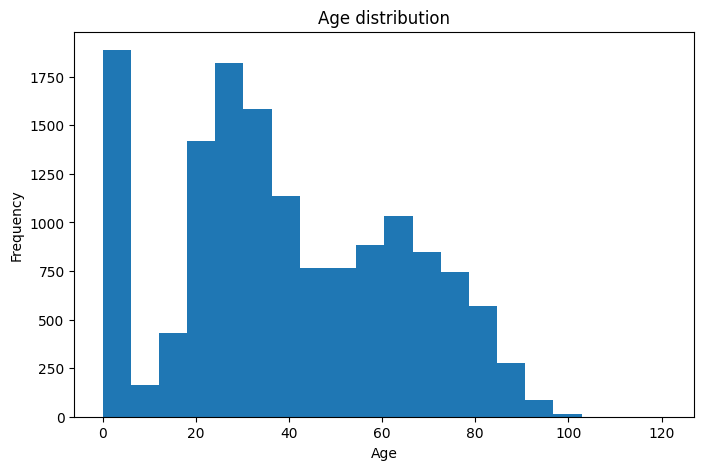

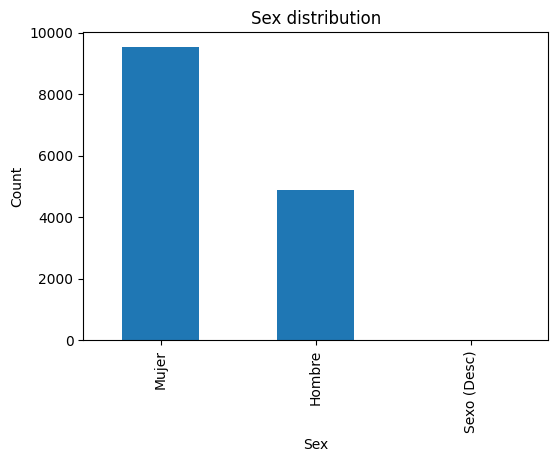

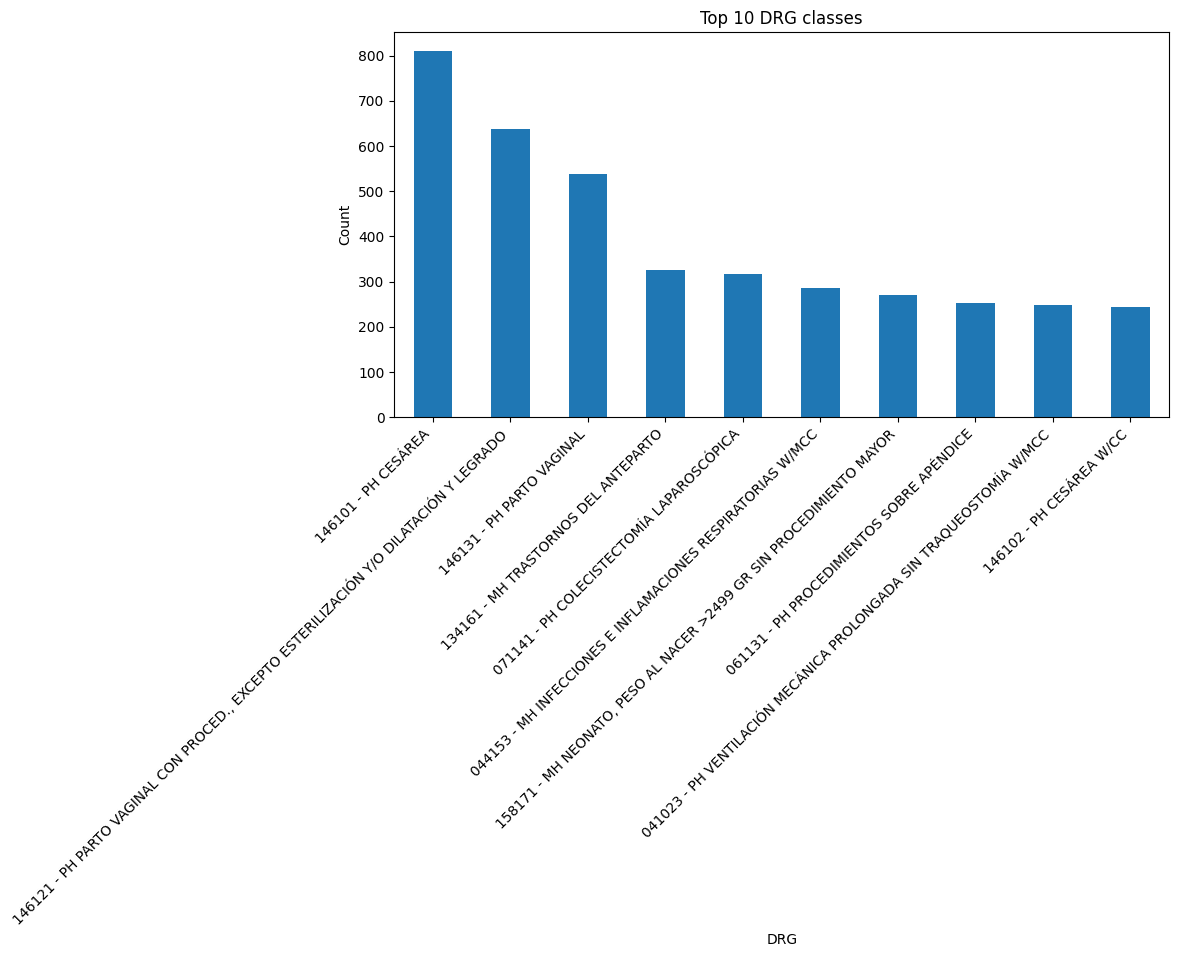

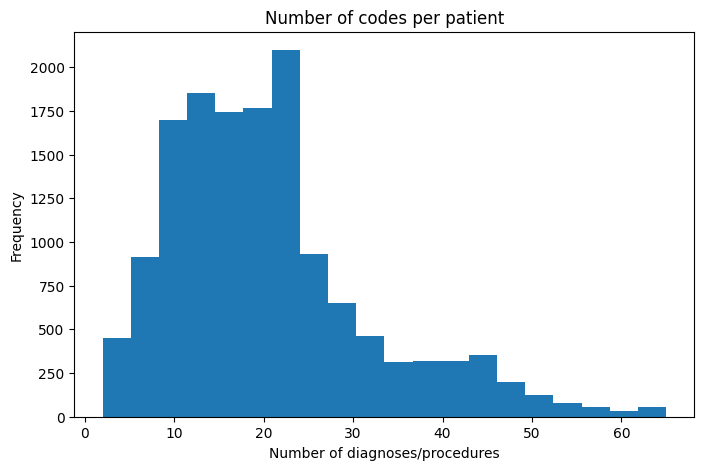

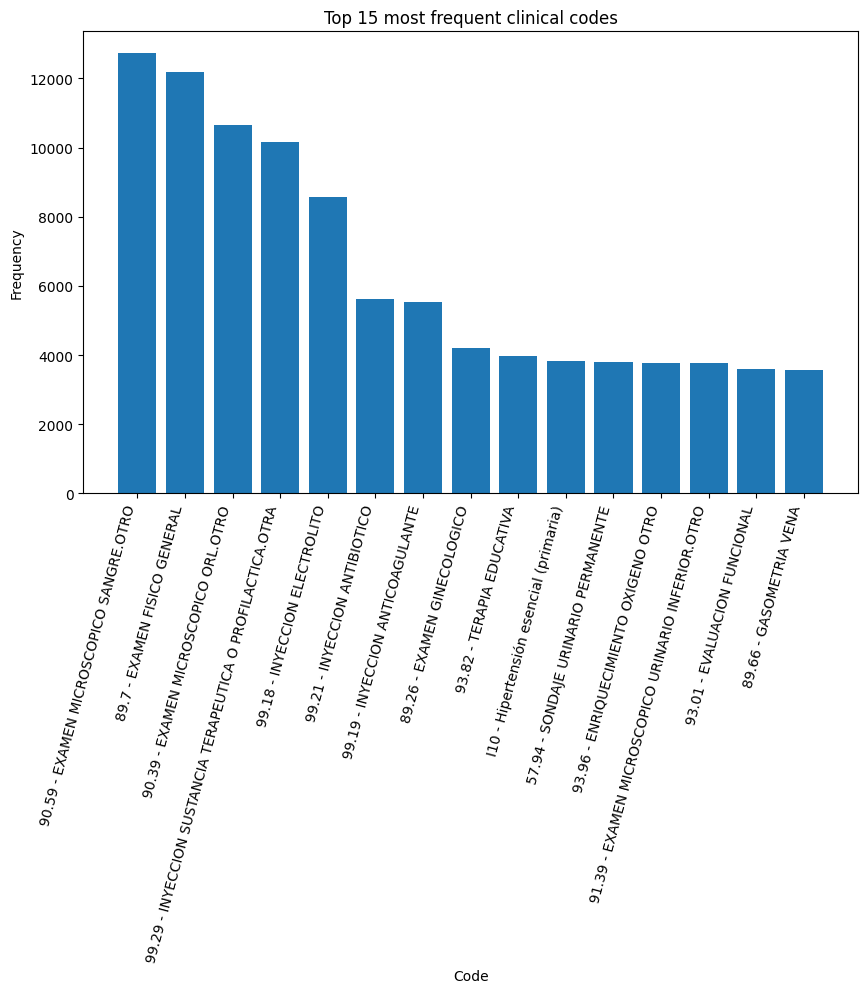

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["age"].dropna(), bins=20)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Distribución de sexo
plt.figure(figsize=(6,4))
df["sex"].value_counts().plot(kind="bar")
plt.title("Sex distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# Top 10 GRD
plt.figure(figsize=(10,5))
df["grd"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 DRG classes")
plt.xlabel("DRG")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Cantidad de códigos por paciente
plt.figure(figsize=(8,5))
plt.hist(df["n_codes"], bins=20)
plt.title("Number of codes per patient")
plt.xlabel("Number of diagnoses/procedures")
plt.ylabel("Frequency")
plt.show()

# Top 15 códigos clínicos
codes_df = pd.DataFrame(top_codes, columns=["code", "count"])
plt.figure(figsize=(10,6))
plt.bar(codes_df["code"], codes_df["count"])
plt.title("Top 15 most frequent clinical codes")
plt.xlabel("Code")
plt.ylabel("Frequency")
plt.xticks(rotation=75, ha="right")
plt.show()